Environmental Impact of Food Production Research and Analysis
==============================================================

Food production is one of the most significant contributors to environmental degradation, including issues such as climate change, water scarcity and biodiversity loss. The agricultural sector's environmental footprint varies widely across different food products, farming methods and geographical locations. Understanding the environmental impacts of food production is essential for developing more sustainable practices, reducing ecological footprints and making informed policy and consumer choices.

The goal of this project is to assess the environmental impact of food production at both macro and micro levels and propose data-driven insights to mitigate the negative effects of food production on the environment. This will help policy-makers, environmentalists, food producers and consumers make more informed decisions that support sustainability.

The analyses followed the CRISP-DM methodology, which includes the following stages:

**1.Business Understanding:**

The objectives were defined below, followed by the formulation of analytic questions to guide the analysis:

a. Assess the environmental impact of food production: Analyse the environmental impact of these different food products based on key metrics such as water usage, land use, carbon emissions.

b. Compare food production methods: Evaluate how various farming techniques (plant based versus animal based) affect environmental sustainability.

c. Identify high-impact food products: Determine which food contribute the most to environmental degradation and assess their sustainability

d. Provide data-driven insights: Develop actionable recommendations to reduce the footprint of food production, targeting policy-makers, food producers and consumers.

e. Promote sustainable food systems: Suggest strategies to transition toward more sustainable agricultural practices that minimise environmental harm.

Analytic questions:

I. What is the correlation between land use and carbon emissions for different food products?

II. How does eutrophication (nutrient run-off) vary among different types of food production?

III. How do plant-based and animal-based food compare in terms of total carbon emissions per kg of product?

IV. Which food products have the highest total greenhouse gas emissions?

V. Which food products have the highest eutrophication potential (nutrient runoff)?

What are the main contributors to greenhouse gas emissions in food production and how can they be reduced?

VII. What policy interventions (e.g., carbon taxes, incentives for sustainable farming) could help reduce the environmental footprint of food production?

**2.Data Understanding:** The dataset contains most 43 most common food grown across the globe and 23 columns as their respective land, water usage and carbon footprints. Variables include:

a. Land use change - Kg CO2 - equivalents per kg product

b. Animal Feed - Kg CO2 - equivalents per kg product

c. Farm - Kg CO2 - equivalents per kg product

d. Processing - Kg CO2 - equivalents per kg product

e. Transport - Kg CO2 - equivalents per kg product

f. Packaging - Kg CO2 - equivalents per kg product

g. Retail - Kg CO2 - equivalents per kg product

These represent greenhouse gas emissions per kg of food product(Kg CO2 - equivalents per kg product) across different stages in the life-cycle of food production.

**3. Data Preparation**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read the dataset 
data = pd.read_csv("./Food_Production.csv")

data.head()

,Food product,Land use change,Animal Feed,Farm,Processing,Transport,Packging,Retail,Total_emissions,Eutrophying emissions per 1000kcal (gPO₄eq per 1000kcal),...,Freshwater withdrawals per 100g protein (liters per 100g protein),Freshwater withdrawals per kilogram (liters per kilogram),Greenhouse gas emissions per 1000kcal (kgCO₂eq per 1000kcal),Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein),Land use per 1000kcal (m² per 1000kcal),Land use per kilogram (m² per kilogram),Land use per 100g protein (m² per 100g protein),Scarcity-weighted water use per kilogram (liters per kilogram),Scarcity-weighted water use per 100g protein (liters per 100g protein),Scarcity-weighted water use per 1000kcal (liters per 1000 kilocalories)
0,Wheat & Rye (Bread),0.1,0.0,0.8,0.2,0.1,0.1,0.1,1.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Maize (Meal),0.3,0.0,0.5,0.1,0.1,0.1,0.0,1.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Barley (Beer),0.0,0.0,0.2,0.1,0.0,0.5,0.3,1.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Oatmeal,0.0,0.0,1.4,0.0,0.1,0.1,0.0,1.6,4.281357,...,371.076923,482.4,0.945482,1.907692,2.897446,7.6,5.846154,18786.2,14450.92308,7162.104461
4,Rice,0.0,0.0,3.6,0.1,0.1,0.1,0.1,4.0,9.514379,...,3166.760563,2248.4,1.207271,6.267606,0.759631,2.8,3.943662,49576.3,69825.77465,13449.891480


In [3]:
# Rename packging
data.rename(columns={'Packging':'Packaging'}, inplace=True)

In [4]:
# View columns names
print(data.columns)

Index(['Food product', 'Land use change', 'Animal Feed', 'Farm', 'Processing',
       'Transport', 'Packaging', 'Retail', 'Total_emissions',
       'Eutrophying emissions per 1000kcal (gPO₄eq per 1000kcal)',
       'Eutrophying emissions per kilogram (gPO₄eq per kilogram)',
       'Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)',
       'Freshwater withdrawals per 1000kcal (liters per 1000kcal)',
       'Freshwater withdrawals per 100g protein (liters per 100g protein)',
       'Freshwater withdrawals per kilogram (liters per kilogram)',
       'Greenhouse gas emissions per 1000kcal (kgCO₂eq per 1000kcal)',
       'Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein)',
       'Land use per 1000kcal (m² per 1000kcal)',
       'Land use per kilogram (m² per kilogram)',
       'Land use per 100g protein (m² per 100g protein)',
       'Scarcity-weighted water use per kilogram (liters per kilogram)',
       'Scarcity-weighted water use per 100g protein

In [5]:
# Check the structure of the dataset 
data.dtypes

Food product                                                                object
Land use change                                                            float64
Animal Feed                                                                float64
Farm                                                                       float64
Processing                                                                 float64
Transport                                                                  float64
Packaging                                                                  float64
Retail                                                                     float64
Total_emissions                                                            float64
Eutrophying emissions per 1000kcal (gPO₄eq per 1000kcal)                   float64
Eutrophying emissions per kilogram (gPO₄eq per kilogram)                   float64
Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)      float64
Fres

In [6]:
# Check for duplicates
sum(data.duplicated())

0

In [7]:
# Check for NA's
data.isnull().sum()

Food product                                                                0
Land use change                                                             0
Animal Feed                                                                 0
Farm                                                                        0
Processing                                                                  0
Transport                                                                   0
Packaging                                                                   0
Retail                                                                      0
Total_emissions                                                             0
Eutrophying emissions per 1000kcal (gPO₄eq per 1000kcal)                   10
Eutrophying emissions per kilogram (gPO₄eq per kilogram)                    5
Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)      16
Freshwater withdrawals per 1000kcal (liters per 1000kcal)       

To maintain data integrity and avoid biased imputations, the missing values were dropped.

In [8]:
# Drop missing values or Na's
data.dropna(inplace=True)

In [9]:
# Export the cleaned data 
data.to_csv("./cleaned_data.csv", index=False)

**4. Analysis and Visualisation**

In [10]:
# Summary Statistics
data['Total_emissions'].describe()

count    24.000000
mean      8.362500
std      13.452939
min       0.200000
25%       0.375000
50%       2.600000
75%       9.525000
max      59.600000
Name: Total_emissions, dtype: float64

The minimum total emission is 0.200 and the maximum total emission is 59.600.

1St Quartile: 25% of the total emission falls under 0.38.

3Rd Quartile: 25% of the total emission is above 9.53 or 75% of the total emission falls under 9.53.

Skewness: The median (2.60) and mean(8.36) indicates, the distribution is skewed. The mean being greater than the median shows a positive skewness, that is, skewed to the right or right skewed.

**Data visualisation of the top ten total emissions (Kg CO2) by food products**

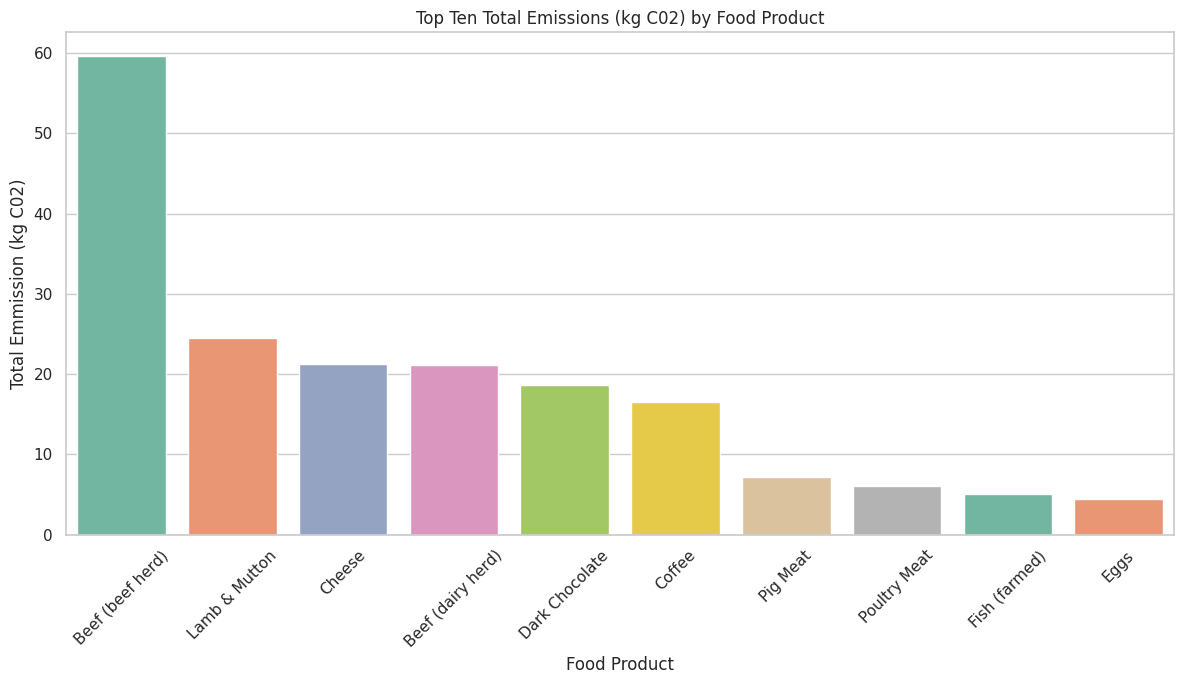

In [11]:
# Group the data by food product 

food_product_data = (
    data.groupby('Food product')
        .agg(Total_Emissions=('Total_emissions', 'sum'))
        .reset_index()
    )

# Sort by total emission in descending order and limit to the top 10
food_product_data=food_product_data.sort_values(by='Total_Emissions', ascending=False).head(10)

# Visualize the data
plt.figure(figsize=(12, 7))
sns.set(style='whitegrid')

sns.barplot(
    data=food_product_data,
    x="Food product",
    y="Total_Emissions",
    palette='Set2',
    hue='Food product'
)

# Customize the plot
plt.title("Top Ten Total Emissions (kg C02) by Food Product")
plt.xlabel("Food Product")
plt.ylabel("Total Emmission (kg C02)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The bar chart depicts the distribution of the top ten total emissions by food products. The y-axis shows total emissions whilst the x-axis lists different food products. Each food product is represented by a unique colour in the legend on the right.

From the chart, Beef (beef herd) demonstrates the highest emissions by a considerable margin followed by Beef (dairy herd) which also has significant emissions but substantially lower in comparison. The remaining food products have relatively minor emissions compared to beef.

This indicates that beef production has a significantly higher environmental impact regarding emissions compared to other food products.

According to the World Wildlife Fund (2025), Beef production has a higher environmental impact than other food sources due to factors like land use for grazing and crop production, greenhouse gas emissions from cattle and water pollution from waste run-off as well as deforestation from cattle ranching.

**Land Use**

As stated by the Beef Research Council, beef production requires vast amounts of land both for grazing cattle and for growing feed crops. Globally, a significant portion of agricultural land is used for livestock including cattle and a large area of rainforests is destroyed to create grazing land.

**Greenhouse Gas Emissions**

Cattle are a major source of greenhouse gas emissions particularly methane which is a potent greenhouse gas. Methane is released during the digestive process of cattle and also from manure management. The production of feed crops for cattle also contributes to greenhouse gas emissions (Beef Research Council, 2025).

**Water Pollution**

Cattle waste, if not properly managed, can pollute water sources with nitrates, phosphorus and pathogens. Water used for livestock production can also be a significant burden on water resources especially in arid regions (Beef Research Council, 2025). The Food and Agriculture Organisation has written, "The livestock sector is growing and intensifying faster than crop production in almost all countries. The associated waste including manure has serious implications for water quality (Rosie's Farm Sanctuary, 2025).

**Deforestation**

Cattle ranching is a major driver of deforestation especially in regions like the Amazon rainforest where land is cleared to create grazing pastures. Deforestation contributes to climate change, biodiversity loss and soil degradation (Rosie's Farm Sanctuary, 2025).

**Data visualisation of plant-based and animal-based on land use (m² per 100g protein) versus greenhouse gas emissions (kg CO2-eq per 100g protein)**

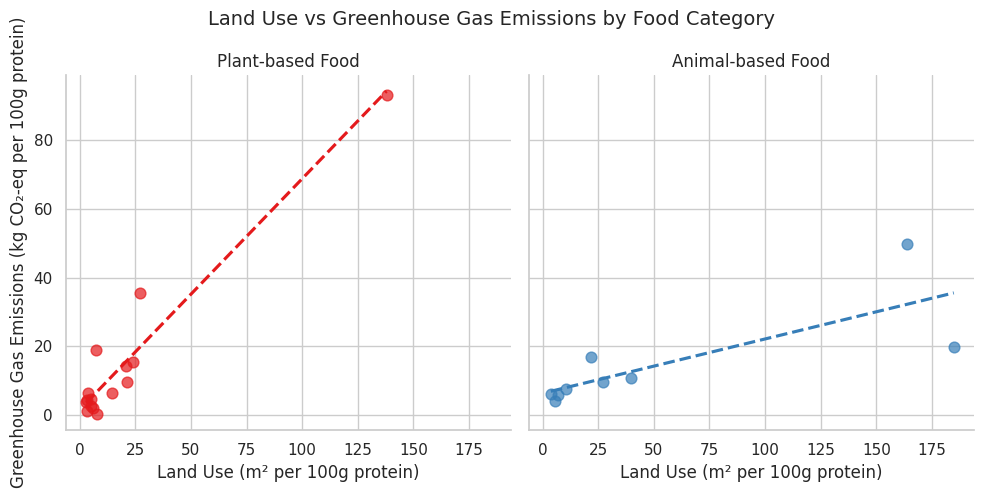

In [12]:
plant_products = [
    "Oatmeal", 
    "Rice", 
    "Potatoes", 
    "Nuts", 
    "Groundnuts", 
    "Tomatoes", 
    "Onions & Leeks", 
    "Root Vegetables", 
    "Brassicas", 
    "Citrus Fruit", 
    "Bananas", 
    "Apples", 
    "Berries & Grapes", 
    "Coffee", 
    "Dark Chocolate"
    ]

data['Category'] = np.where(
    data['Food product'].isin(plant_products),
    'Plant-based',
    'Animal-based'
)

# data['category'] = data['Food product'].apply(
#     lambda x: 'Plant-based' if x in plant_products else 'Animal-based'
# )


# Set the category column to the first
cols = ['Category'] + [col for col in data.columns if col != 'Category']
data = data[cols]

# Create a  facet scatterpkot with linear regression lines
sns.set(style="whitegrid")

plot = sns.lmplot(
    data=data,
    x='Land use per 100g protein (m² per 100g protein)',
    y='Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein)',
    hue='Category',
    col='Category',
    palette='Set1',
    scatter_kws={'s': 60, 'alpha': 0.7},
    line_kws={'linestyle': 'dashed'},
    ci=None
)


# Customize plot titles and labels
plot.set_axis_labels("Land Use (m² per 100g protein)", "Greenhouse Gas Emissions (kg CO₂-eq per 100g protein)")
plot.set_titles("{col_name} Food")
plt.subplots_adjust(top=0.85)
plot.fig.suptitle("Land Use vs Greenhouse Gas Emissions by Food Category", fontsize=14)



# Place legend at the bottom
# plot._legend.set_title("Category")
# plot._legend.set_bbox_to_anchor((0.5, -0.05))
# plot._legend.set_loc("lower center")

plt.show()

The scatter plot examines the relationship between land use (x-axis, measured in m² per 100g protein) and greenhouse gas emissions (y-axis, measured in kg CO₂eq per 100g protein) across different food categories. The visualisation separates animal-based foods (red points with dashed red trend line) from plant-based foods (blue points with dashed blue trend line).

According to the specific dataset presented in this scatter plot, the animal-based category shown appear to use less land per 100g of protein than some plant-based category. The red points are clustered primarily in the lower range of the x-axis (0-150 m² per 100g protein).

The relatively flat trend line for animal-based category suggests that within this category, increasing land use does not correspond to proportionally higher emissions. However, several animal-based cateogry still show moderate to high greenhouse gas emissions despite their lower land use footprint in this dataset.

**Plant-Based Category**

Plant-based Category display greater variability in both land use and emissions. While most plant-based options in this dataset show low emissions and low land use (clustered in the bottom left of the right panel), there is a notable outlier: One plant-based food requires close to 150 m² per 100g protein while producing nearly 100 kg CO₂eq, significantly higher than all other food in both categories.The steeper trend line for plant-based food indicates that within this category, higher land use correlates more strongly with increased emissions.

This specific dataset appears to show a subset of food that may not represent the full spectrum of animal and plant-based products. Typical comprehensive studies by Our World in Data (n.d) generally show animal products requiring substantially more land on average than plant-based alternatives. The outlier plant-based food with extremely high land use and emissions may be representing a specific crop grown in particularly resource-intensive conditions.

**Environmental Implications**

Despite the specific data patterns shown here, transitioning from animal-based to most plant-based proteins would generally benefit emission reduction efforts, as the majority of plant-based options cluster in the low-emissions range.

**Supporting Research**

Global Food Institute stated that, by using plants, fermentation or cell cultivation instead of livestock, the production of alternative proteins does not emit the same toxic air pollutants that is, ammonia, particulate matter and hydrogen sulfide; as conventional meat production. Similarly, because there is no animal waste to discharge and fewer crops and fertilisers are needed, alternative proteins reduce the discharge of nitrogen and phosphorus, which stimulate the growth of algal blooms that impair water quality. A shift toward alternative proteins can keep our air and water clean, improving the health of communities and ecosystems while meeting increasing protein demand.

This visualisation highlights the importance of considering multiple environmental metrics when evaluating food sustainability. While most plant-based foods offer environmental benefits, the data shows significant variability within both categories. For optimal environmental outcomes, focus should be placed on plant-based options with both low land use and low emissions profiles, while avoiding the outlier plant-based options that may be environmentally intensive on both metrics.

**Summary of greenhouse gas emmission (kg CO₂-eq per 100g protein)**

In [14]:
data['Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein)'].describe()

count    24.000000
mean     14.551195
std      20.274536
min       0.263319
25%       4.277181
50%       7.054079
75%      15.692325
max      93.300000
Name: Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein), dtype: float64

The minimum greenhouse gas emission is 0.26, which is very low in CO2 emissions.

1St Quartile: 25% of the food product emission is below 4.28 kg CO₂-eq.

Median: Half of the food products have emissions is 7.05 kg CO₂-eq.

Skewness: The mean is higher than the median, suggesting a right-skewed distribution (some food have extremely high emissions)

3Rd Quartile: 75% of the food have emissions of about 15.69 kg CO₂-eq.

Maximum: The highest emission food products produces 93.3 kg CO₂-eq which is far above the mean, confirming outliers.

Most food have emissions below 16 kg CO₂-eq, but a few high-impact food (an example is beef) push the mean much higher.

**Summary Land Use (m² per 100g protein)**

In [15]:
data['Land use per 100g protein (m² per 100g protein)'].describe()

count     24.000000
mean      31.462307
std       51.860051
min        3.000000
25%        5.132353
50%        9.332804
75%       24.831250
max      184.812594
Name: Land use per 100g protein (m² per 100g protein), dtype: float64

The minimum land use is just 3 m² per 100g protein.

1St Quartile: 25% of the food product requires 5.132 m².

Median: Half of the food product needs 9.33 m².

Mean: Again, much higher than the median, indicating a some food products take up a lot of land.

3Rd Quartile: 75% of food require 24.83 m²

Maximum: Food products require almost 185 m² per 100g protein which is massively higher than the rest (likely beef).

**Box plot to detect outliers in Greenhouse Gas Emissions (kg CO₂-eq per 100g protein)**

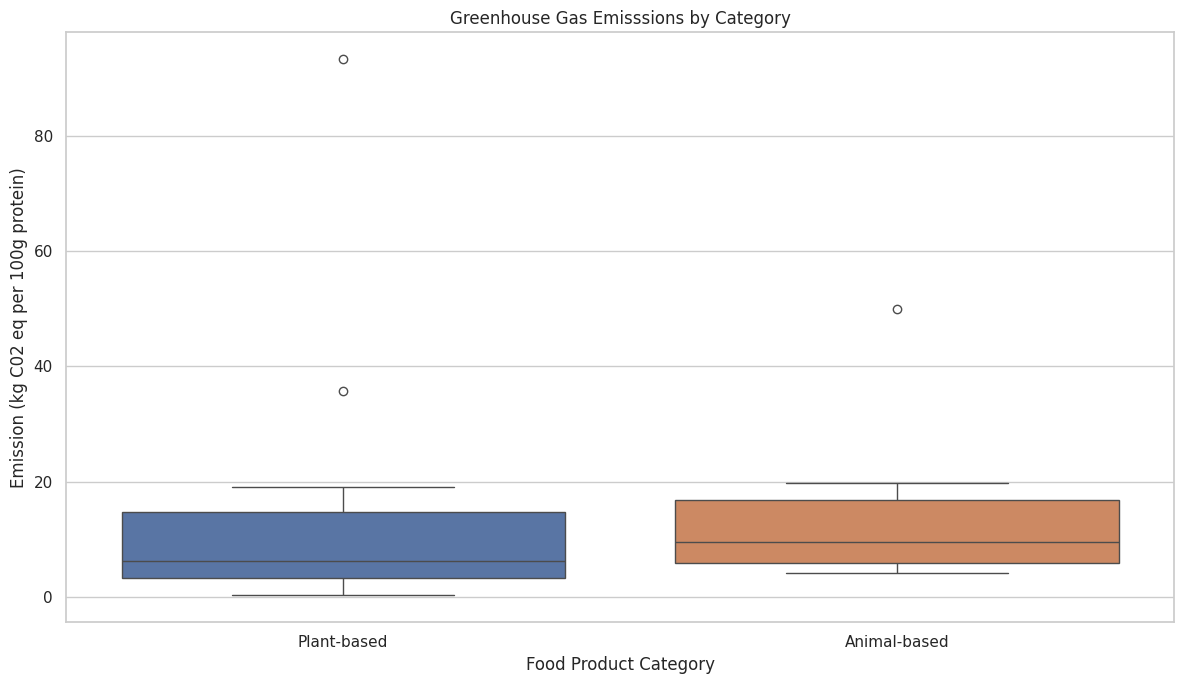

In [21]:
plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")

sns.boxplot(
    data=data,
    x='Category',
    y='Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein)',
    hue='Category'
)

plt.title("Greenhouse Gas Emisssions by Category")
plt.xlabel("Food Product Category")
plt.ylabel("Emission (kg C02 eq per 100g protein)")
plt.tight_layout()
plt.show()

The box plot compares greenhouse gas emissions by category. The box is for animal and plant-based food that are quite similar. Both categories have high emission outliers, but the most extreme values is in the plant-based category (one point above 70 kg CO₂-eq). There's also an outlier in the animal-based category at 50 kg CO₂-eq.

**Box plot to detect outliers in Land Use (m² per 100g protein)**

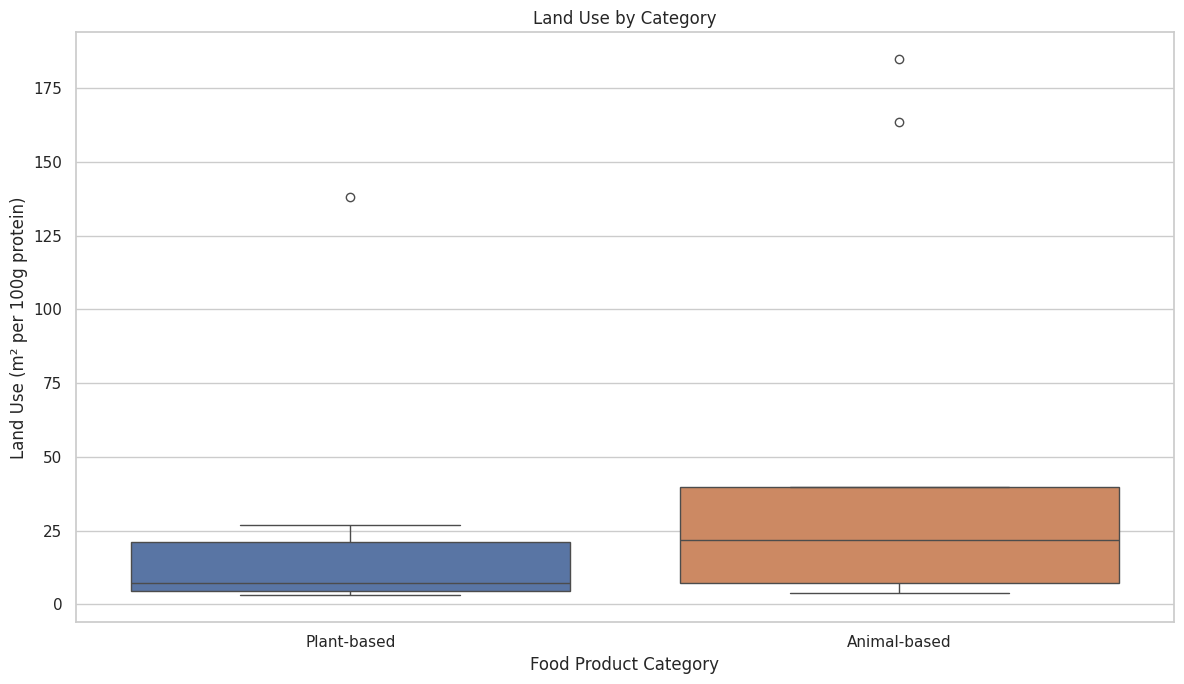

In [22]:
plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")

sns.boxplot(
    data=data,
    x='Category',
    y='Land use per 100g protein (m² per 100g protein)',
    hue='Category'
)

plt.title('Land Use by Category')
plt.xlabel('Food Product Category'),
plt.ylabel('Land Use (m² per 100g protein)')
plt.tight_layout()
plt.show()

The box plot compares land use by food category. Animal-based food has a higher median land use than plant-based food. The IQR is wider for animal-based food, indicating greater variability.

Both categories have extremely high land use outliers. The highest land use (above 150m2 per 100g protein) is likely a type of livestock, likely to be lamb.

Some plant-based food also have a high land use, possibly dark chocolate.

**Data visualisation to investigate the cause of the outlier in greenhouse gas emissions box plot**

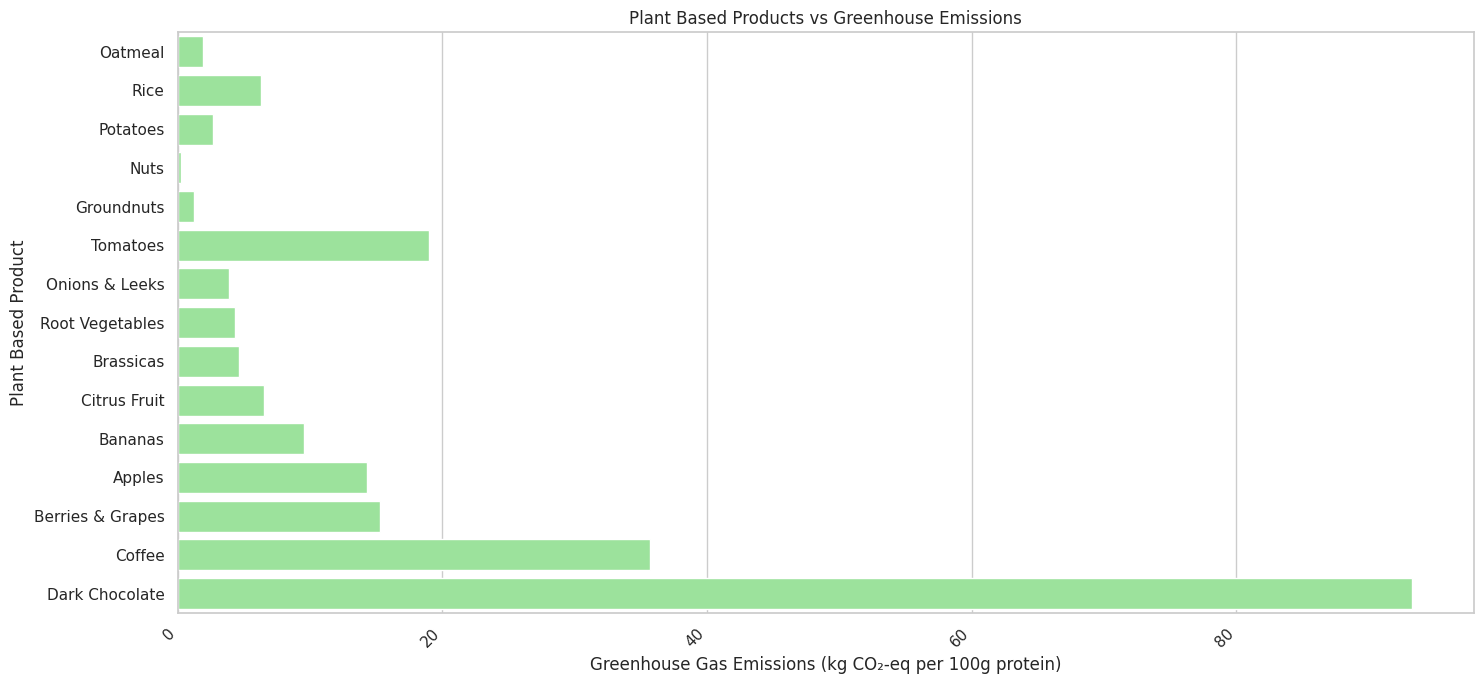

In [49]:
plant_based_product = data[data['Category'] == 'Plant-based'][[
    'Category',
    'Food product',
    'Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein)'
]]

plt.figure(figsize=(15, 7))
sns.set(style='whitegrid')

sns.barplot(
    data=plant_based_product,
    y='Food product',
    x='Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein)',
    color='lightgreen',
)

plt.title("Plant Based Products vs Greenhouse Emissions")
plt.xlabel('Greenhouse Gas Emissions (kg CO₂-eq per 100g protein)')
plt.xticks(rotation = 45, ha ='right')
plt.ylabel('Plant Based Product')
plt.tight_layout()
plt.show()

**Exploratory Data Analysis (EDA) On Water Use (Freshwater Withdrawals & Scarcity-Weighted Water Use)**

Data Visualisation on top freshwater consuming food products litres per 1000kcal

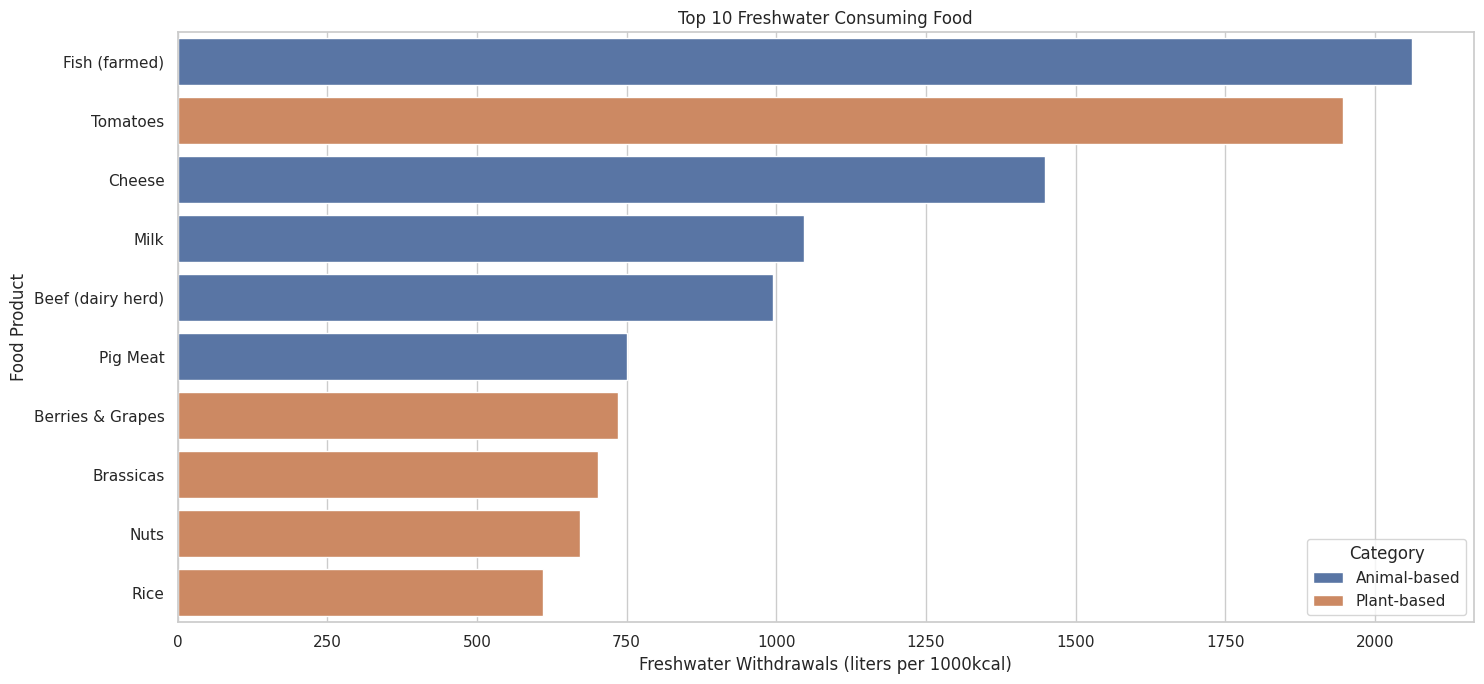

In [48]:
# Select top 10 highest water consuming food 
top_water_food = data.sort_values(
    by='Freshwater withdrawals per 1000kcal (liters per 1000kcal)',
    ascending=False
).head(10)


plt.figure(figsize=(15, 7))
sns.set(style='whitegrid')

sns.barplot(
    data=top_water_food,
    x='Freshwater withdrawals per 1000kcal (liters per 1000kcal)',
    y='Food product',
    hue='Category'
)

plt.title('Top 10 Freshwater Consuming Food')
plt.xlabel('Freshwater Withdrawals (liters per 1000kcal)')
plt.ylabel('Food Product')
plt.tight_layout()
plt.show()

The bar chart depicts the distribution of the top ten water-consuming food products. Farmed fish is the highest water consumer, followed by Tomatoes and Cheese. Rice and Nuts are also water consumers.

Farmed Fish, Cheese, Milk, Beef (dairy herd), Pig Meat are the most water-intensive animal-based food products in this ranking.

While all food production requires water, plant-based food generally require significantly less water than animal products, making them a more water-efficient choice (Colorado Sun, 2022). Animal agriculture consumes high amounts of water and pollutes freshwater ecosystems (Livvie, 2025) also, raising livestock, especially beef, requires vast amounts of water for feed production, drinking water, and cleaning (Livvie, 2025).

From the chart, tomatoes are the most water-consuming plant-based food product, which is supported by EOS (2025), stating that tomato cultivation can be water-intensive, with some studies suggesting that producing 1 kg of tomatoes can require anywhere from 4 to 300 liters of water, depending on the growing method and efficiency.

Environmental Impact

Excessive freshwater withdrawal can lead to depletion of water sources that is reduced water availability for other uses and ecosystems. It can also lead to water quality degradation; pollution from fish farm effluent (waste) can contaminate water sources. Changes in flow of water and quality can harm aquatic habitats and species which can lead to ecosystem disruption.

Supporting Research

Fish farming relies heavily on freshwater resources and the intensity of freshwater withdrawal is an important factor in the sustainability of this industry (Leroy Seafood, 2021).

**Box plot on plant-based versus animal-based scarcity- weighted use litres per 1000kcal**

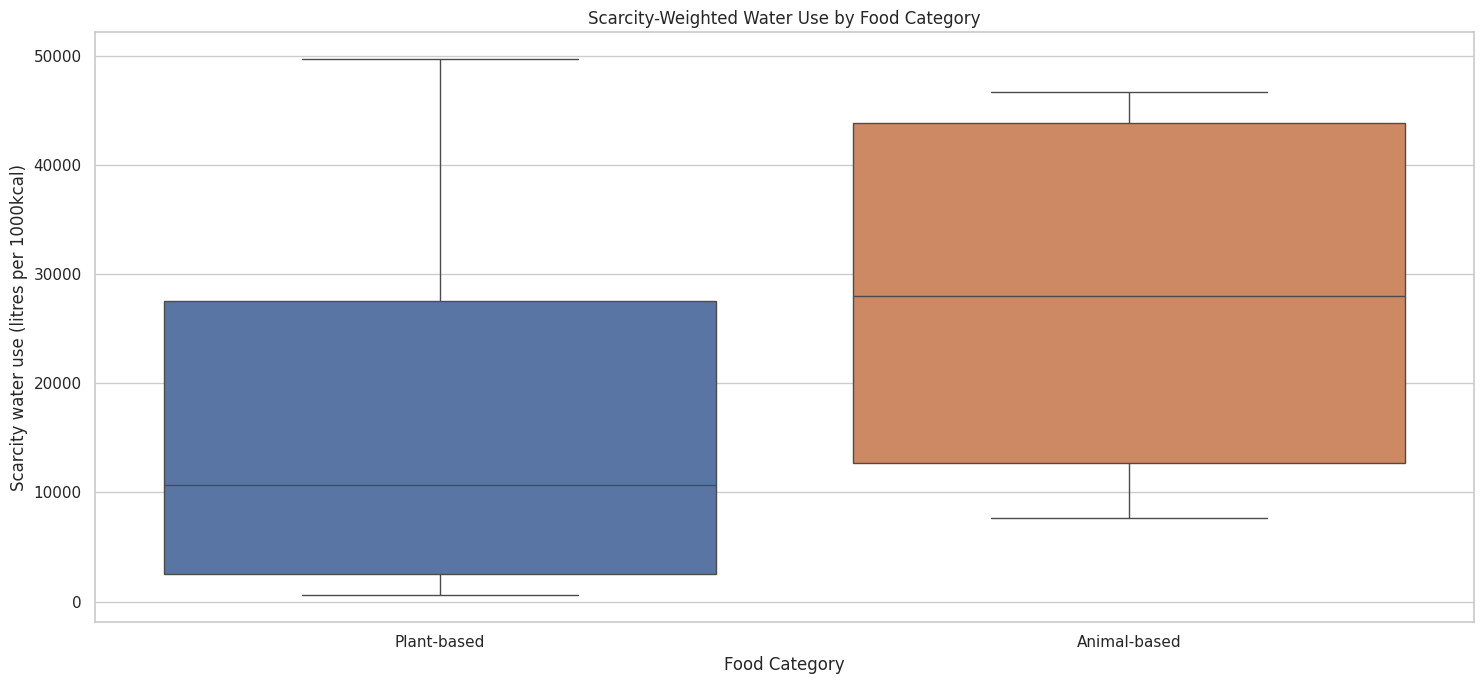

In [47]:
plt.figure(figsize=(15, 7))

sns.set(style="whitegrid")

sns.boxplot(
    data=data,
    x='Category',
    y='Scarcity-weighted water use per 1000kcal (liters per 1000 kilocalories)',
    hue='Category'
)

plt.title("Scarcity-Weighted Water Use by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Scarcity water use (litres per 1000kcal)")
plt.tight_layout()
plt.show()

This box plot compares scarcity-weighted water use (litres per 1000 kcal) for animal-based and plant-based food categories.

Animal-based food have a higher median and spread of scarcity-weighted water use than plant-based food.The variation within plant-based food shows relatively low water use while others have values close to animal-based food.

The scarcity-weighted water use box-plot doesn't show distinct outliers. The distribution suggests that both animal-based and plant-based food have a wide range, but no extreme points that fall significantly outside the whiskers.

Supporting Research

Plant-based food require less water than animal-based food. This is because raising livestock needs large amounts of water for animal consumption and feed production (Livvie, n.d). 


**Scatter Plot: Freshwater Withdrawals (litres per 1000kcal) versus Scarcity-Weighted Water Use (litres per 1000kcal)**

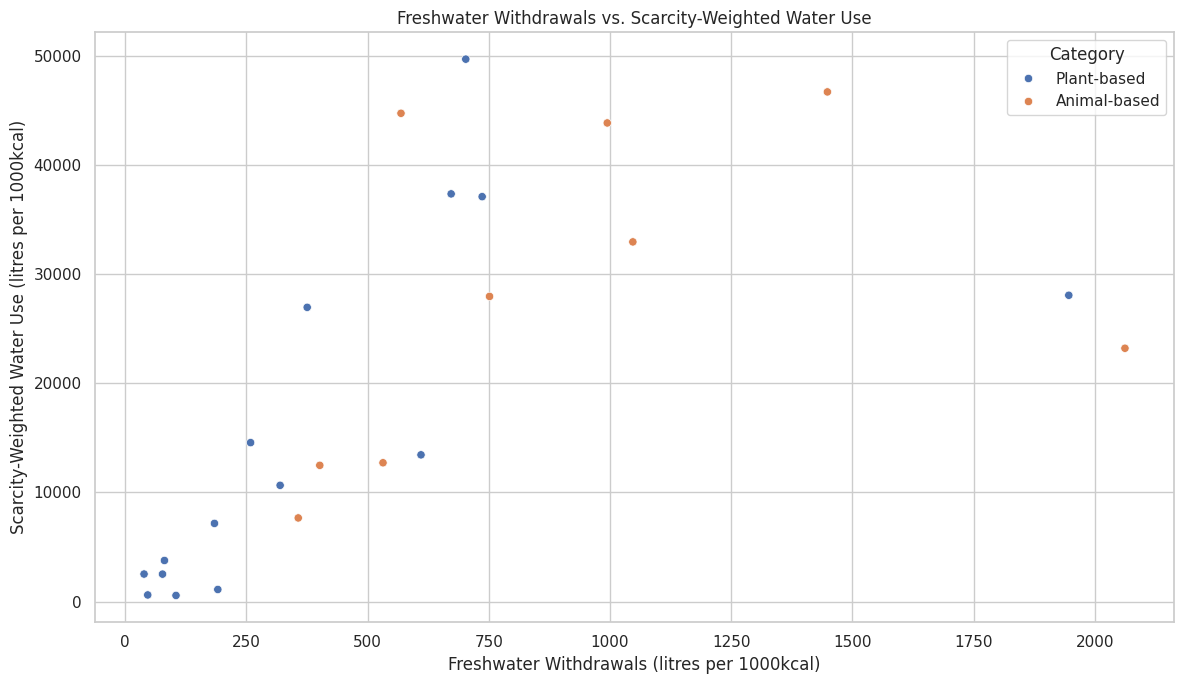

In [52]:
plt.figure(figsize=(12, 7))

sns.set(style='whitegrid')

sns.scatterplot(
    data=data,
    x='Freshwater withdrawals per 1000kcal (liters per 1000kcal)',
    y='Scarcity-weighted water use per 1000kcal (liters per 1000 kilocalories)',
    hue='Category'
)

plt.title('Freshwater Withdrawals vs. Scarcity-Weighted Water Use')
plt.xlabel('Freshwater Withdrawals (litres per 1000kcal)')
plt.ylabel('Scarcity-Weighted Water Use (litres per 1000kcal)')
plt.tight_layout()
plt.show()

The scatter plot shows a distribution of freshwater withdrawals versus scarcity weighted water use.

Freshwater withdrawals (litres per 1000kcal) measures the total amount of water taken from sources, while scarcity-weighted water use (litres per 1000kcal) considers the water's availability and stress levels in the region where it's used.

Both plant-based and animal-based food show variation in how their water use translates into environmental stress.

**Exploratory Data Analysis (EDA) on Eutrophication (g PO4eq per 100g protein)**

Eutrophication is the pollution of water bodies and ecosystems with excess nutrients mostly nitrogen and phosphorus, leading to algal blooms (Wikipedia). Eutrophication is a major environmental problem. The runoff of nitrogen and other nutrients from agricultural production systems is a leading contributor.According to wikipedia, the algal blooms can deplete the level of oxygen in the water, creating what is called "dead zones" that harm aquatic life. The degradation of these algae also leads to oxygen consumption in lake bottoms, which causes problems for fish and other aquatic species.

**Data visualisation on the top 10 food products with the highest eutrophication impact**

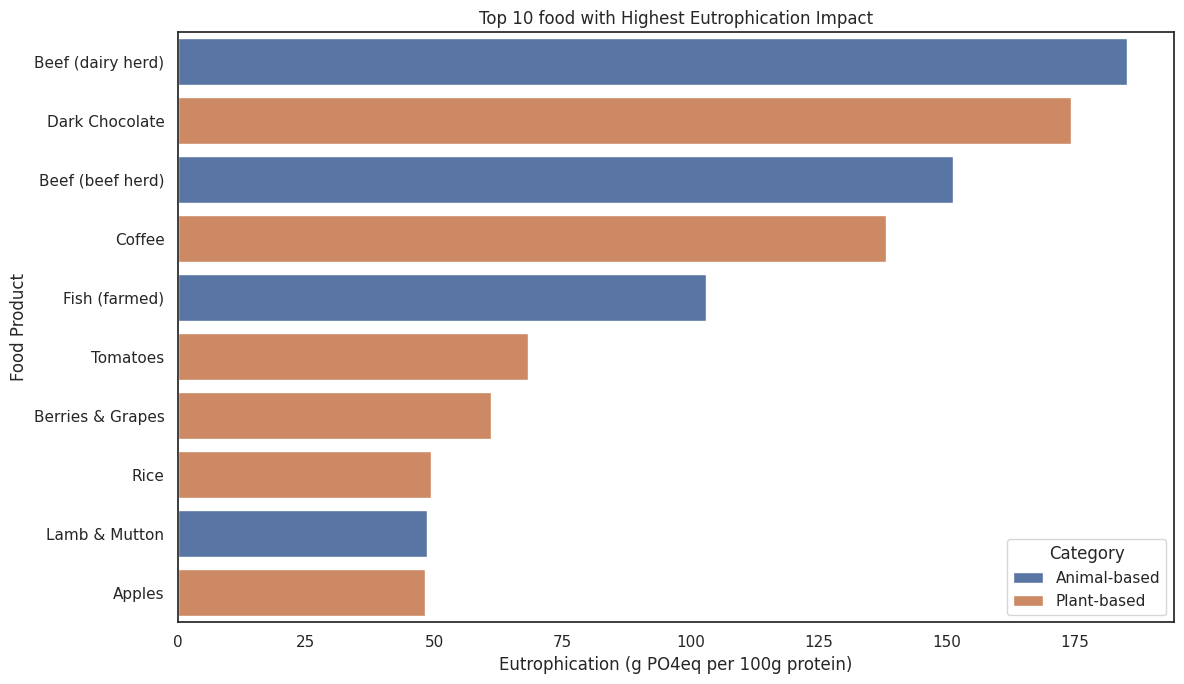

In [54]:
top10_eutro = data.sort_values(
    by='Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)',
    ascending=False,
).head(10)

plt.figure(figsize=(12, 7))

sns.set(style="white")

sns.barplot(
    data=top10_eutro,
    x='Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)',
    y='Food product',
    hue='Category'
)

plt.title('Top 10 food with Highest Eutrophication Impact')
plt.xlabel('Eutrophication (g PO4eq per 100g protein)')
plt.ylabel('Food Product')
plt.tight_layout()
plt.show()

Eutrophying emissions represent run-off of excess nutrients into the surrounding environment and waterways, which affect and pollute ecosystems (Our World in Data, 2025). They are measured in grams of phosphate equivalents (PO₄eq).

This bar chart shows the top 10 food with the highest eutrophication impact, measured in g PO₄eq per 100g protein. Beef (dairy herd) has the highest eutrophication impact, making it the most significant contributor to nutrient pollution. Dark chocolate and coffee, both plant-based, rank among the top contributors, indicating that some plant food also have high eutrophication footprint.

Beef (beef herd) and farmed fish continue to show high impacts, reinforcing the significant role of animal-based products.

Tomatoes, berries & grapes, rice and apples highlight that certain crops also have notable eutrophication impacts, likely due to fertilizer use.

**Environmental Impact of Beef**
Beef production is associated with high eutrophication which is due to runoff from manure and overall environmental impact of livestock farming especially compared to plant-based alternatives.

**Manure Runoff:** Large amounts of water is generated when it comes to beef production, which has high nitrogen and phosphorus levels. Eutrophication is caused when this manure runs off into waterways. Eutrophication is 59 times higher than beef in terms of kilograms due to it runoff from manure (Poore & Nemeck, 2018).

**Land Use:** Beef production needs extensive land for grazing and feed crops, which leads to deforestation and degradation of land. This can also be a factor to soil erosion and nutrient runoff.

**Greenhouse Gas Emissions:** Cattle product the significant amount fo methane, a greenhouse gas that contributes to change in climate and also heightening eutrophication issues.

**Environmental Impact of Coffee**
Ohio State Pressbooks states that, coffee production and processing is a factor that contirbutes to eutrophication. Coffee processing generates large amount of organic waste, including pulp and other residues, which are often discharged into nearby waterways (Hugo Coffee). This organic waste contains nutrients such as nitrogen and phosphorus, when entering water bodies, can lead to excessive growth of algal (eutrophication).

Coffee processing and the consumption of coffee has contributed to caffeine contamination in water, which has negative impacts on aquatic ecosystem (Butler, R.A., 2022).

**Environmental Impact of dark chocolate**
Chocolate in itself does not directly cause eutrophication, its consumption and production contribute to it through the environmental impacts of cocoa farming, chocolate manufacturing and packaging with it main concern in water usage, deforestation and energy consumption.

**A Breakdown of how chocolate contributes to eutrophication:**
**Raw Material Production:** A major component of chocolate production is cocoa farming, which leads to deforestation, soil degradation and the use of fertilisers and other agrochemical products, all of which can contribute to nutrient runoff into waterways, leading to eutrophication.

**Manufacturing Processes:** In chocolate manufacturing, the intensive processes such as drying, roasting and refining can contribute to greenhouse gas emissions and energy consumption.

**Packaging and Transportation:** The packaging materials used for chocolate and the transportation of cocoa beans and finished products can have impact on the environment, which includes depletion of resource and waste generation.

**Water Footprint:** The production of cocoa and chocolate needs a lot of water and water pollution from agricultural runoff and industrial processes contributes to eutrophication.

**Cocoa Derivatives:** Cocoa derivatives, a key ingredient in dark chocolate, contribute heavily to eutrophication potential (Butler, R.A., 2022).

**Box plot to assess the impact of eutrophication (g PO4eq per 100g protein) by food category**

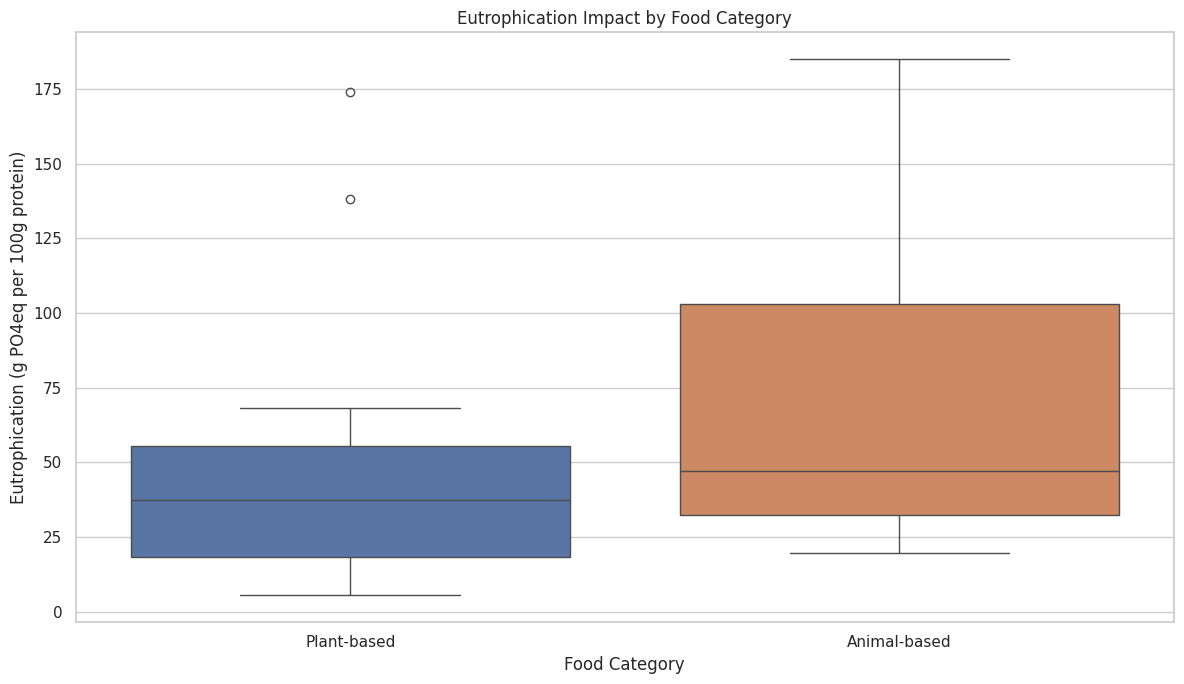

In [56]:
plt.figure(figsize=(12, 7))

sns.set(style='whitegrid')


sns.boxplot(
    data=data,
    x='Category',
    y='Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)',
    hue='Category'
)

plt.title('Eutrophication Impact by Food Category')
plt.xlabel('Food Category')
plt.ylabel('Eutrophication (g PO4eq per 100g protein)')
plt.tight_layout()
plt.show()

This boxplot compares eutrophication impact between animal-based and plant-based food, measured in g PO₄eq per 100g protein. Animal-based food have a higher median eutrophication impact than plant-based food. The interquartile range (IQR) for animal-based food is wider, indicating greater variability in eutrophication impact.

Outliers in plant-based food suggest that certain plant products, have exceptionally high eutrophication impacts.

The maximum values for animal-based food are higher, detailing that livestock farming is a key contributor to eutrophication.

**Scatter Plot on Eutrophication (g PO4eq per 100g protein) versus Greenhouse Gas Emissions (kg CO₂-eq per 100g protein)**

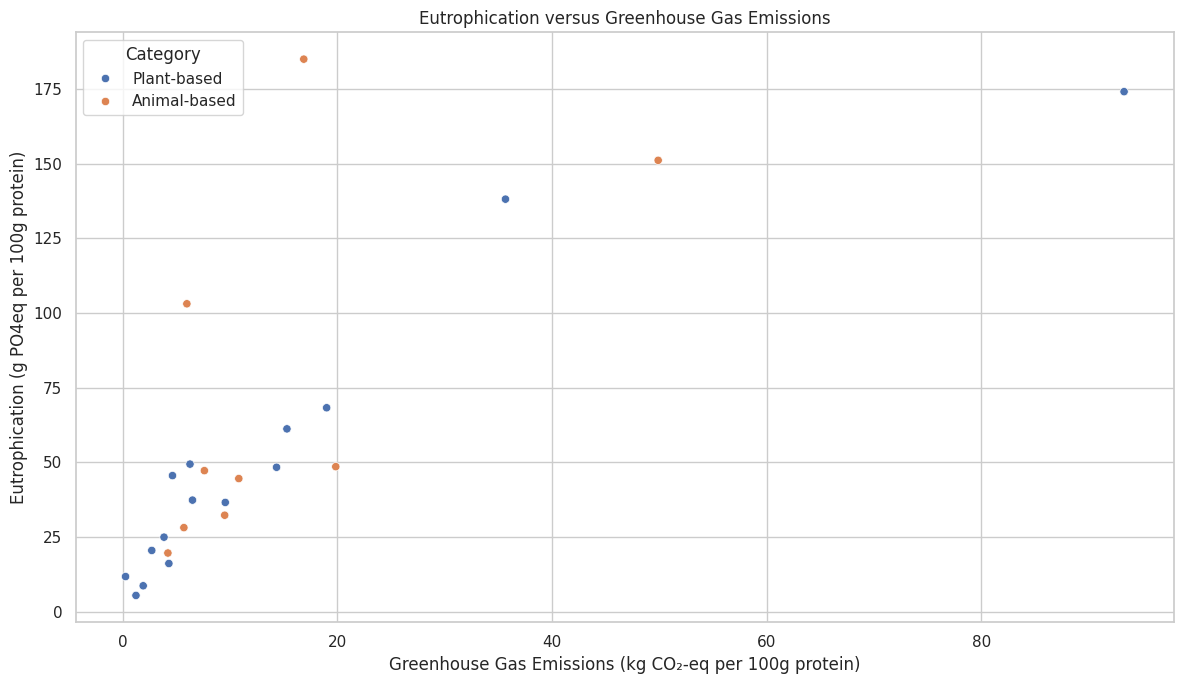

In [58]:
plt.figure(figsize=(12, 7))

sns.set(style='whitegrid')

sns.scatterplot(
   data=data,
   x='Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein)',
   y='Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)',
   hue='Category'
)

plt.title('Eutrophication versus Greenhouse Gas Emissions')
plt.xlabel('Greenhouse Gas Emissions (kg CO₂-eq per 100g protein)')
plt.ylabel('Eutrophication (g PO4eq per 100g protein)')
plt.tight_layout()
plt.show()

The scatter plot shows the relationship between Eutrophication (g PO₄eq per 100g protein) and Greenhouse Gas (GHG) Emissions (kg CO₂-eq per 100g protein).

There appears to be a positive correlation between eutrophication and GHG emissions. A few food products (most likely beef (dairy and beef herd)) are extreme outliers, having both high eutrophication and high GHG emissions. Most food have relatively low eutrophication and GHG emissions, staying in the bottom-left region.

**Supporting Research**

Higher levels of eutrophication increases greenhouse gas emissions to the atmosphere, the emission of CH4 have been observed to increase with eutrophication (DelSontro et al., 2018).

**How eutrophication affects greenhouse gas emission:**

Eutrophication leads to algal blooms, which, upon decompostion, deplete oxygen in the water, creating an environment where anaerobic bacteria thrive. These bacteria produce and release methane and nitrous oxide, both potent greenhouse gases (Science Daily, 2019).

**Calculating the efficiency of environmental impact across all food products by 75%**


In [59]:
# Define reduction percentage
eutrophication_reduction_percentage = 75

# Apply eutrophication reduction 
data['reduced_eutrophication'] = data['Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)'] * (1 - eutrophication_reduction_percentage / 100)

data ['eutrophication_reduction_amount'] = data['Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)'] * (eutrophication_reduction_percentage / 100)

# Calculate totals
total_original = data['Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)'].sum()
total_reduced = data['reduced_eutrophication'].sum()
total_reduction = data['eutrophication_reduction_amount'].sum()

# Print Summary Statistics
print(f"Total Original Eutrophication: {total_original: 2f} g PO₄eq")
print(f"Total Reduced Eutrophication: {total_reduced:.2f} g PO₄eq")
print(f"Total Reduction: {total_reduction:.2f} g PO₄eq")
print(f"Overall Reduction Efficiency: {(total_reduction / total_original) * 100:.2f}%")

Total Original Eutrophication:  1405.814149 g PO₄eq
Total Reduced Eutrophication: 351.45 g PO₄eq
Total Reduction: 1054.36 g PO₄eq
Overall Reduction Efficiency: 75.00%


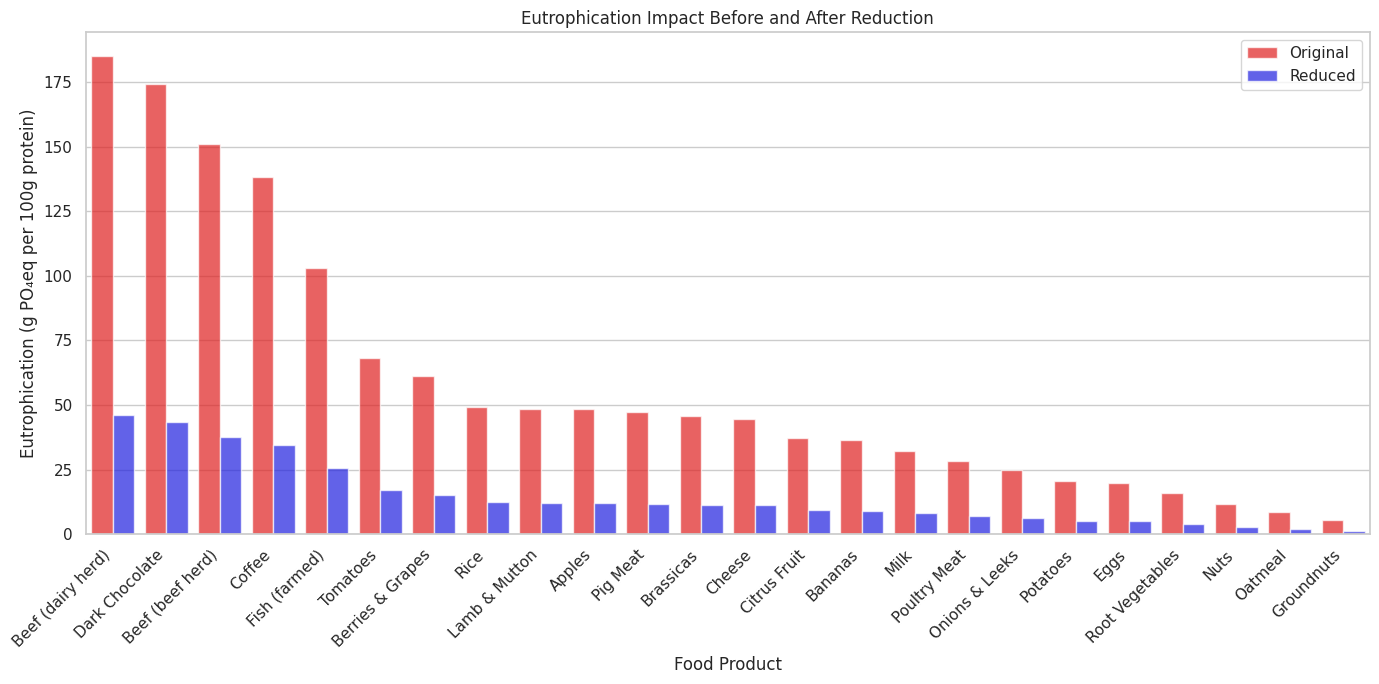

In [60]:
# Select and melt the data for plotting
plot_df = data[['Food product', 'Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)', 'reduced_eutrophication']].copy()

# Rename columns for readability
plot_df.columns = ['Food product', 'Original', 'Reduced']

# Melt to long format
plot_df_long = plot_df.melt(id_vars='Food product', 
                            value_vars=['Original', 'Reduced'], 
                            var_name='Type', 
                            value_name='Eutrophication')

# Sort products by original eutrophication (descending)
food_order = data.sort_values(
    'Eutrophying emissions per 100g protein (gPO₄eq per 100 grams protein)', 
    ascending=False
)['Food product']


plt.figure(figsize=(14, 7))
sns.barplot(
    data=plot_df_long,
    x='Food product',
    y='Eutrophication',
    hue='Type',
    order=food_order,  # keep same product order
    alpha=0.7,
    palette={'Original': 'red', 'Reduced': 'blue'}
)


# Customize labels and appearance
plt.title('Eutrophication Impact Before and After Reduction')
plt.xlabel('Food Product')
plt.ylabel('Eutrophication (g PO₄eq per 100g protein)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='')

plt.tight_layout()
plt.show()

This visualisation displays the eutrophication impact before and after reduction by 75% for various food products. From the chart, Animal-based product dominates the eutrophication impact, that is Beef (dairy herd), Beef (beef herd) and farmed fish have the highest eutrophication values. The reduction (blue portion) still leaves them higher than plant-based product.The chart also shows some plant-based products having notable eutrophication reduction impact. Dark chocolate, Coffee, Tomatoes, Berries & Grapes and Rice show substantial eutrophication values, although they are generally lower than the animal products.The reduction effect by 75% is proportional due to the fact that, high-impact food shows a more noticeable reduction, but they still maintain a significant eutrophication footprint.

**Recommendations & Conclusion**

This document outlines evidence-based strategies to reduce the environmental impact of food production systems, focusing on land use optimisation, greenhouse gas emission reduction, freshwater conservation, water scarcity, eutrophication. These recommendations address the most resource-intensive food categories and propose sustainable alternatives.

**Strategies for land use & greenhouse emission of beef food product**

Global Food Institute (2025), states that using alternative proteins helps reduce air and water pollution significantly. With the use of plants, fermentation and cell cultivation instead of livestock, the production of alternative proteins does not emit the toxic air pollutants including ammonia, hydrogen sulfide and particulate matter as conventional meat production. Also ,there will be no discharge of animal waste. The discharge of nitrogen and phosphorus which stimulates the growth of algal blooms that impair water quality is reduced by using alternative proteins.

Moving towards alternative proteins will promote clean water and air as well as improving ecosystems and the health of communities as it also meets increasing protein demand.

**Alternative Proteins**

Science Direct (2025) states that alternative proteins are healthier, more sustainable and environmentally friendly. Alternative proteins are food products, often meat substitutes, derived from sources other than traditional animal-based proteins, like plant-based proteins, cultured meat or fermented products, aiming to be healthier and more sustainable.

Alternative Proteins are gaining popularity due to concerns about the environmental impact of traditional meat production, as well as growing interest in plant-based diets and healthier eating habits (Liu, 2018).

**Types of Alternative Proteins:**

Plant-based Proteins: These are derived from plants and include plants like legumes, soy, nuts and seeds, grains, mycoprotein (derived from fungi for its meat-like texture) (Finnigan, 2011).

Cultured Meat: Also known as lab-grown meat, this meat is produced from animal cells in a lab, rather than slaughtering animals (Learn About Ag, n.d.).

Fermented Proteins: These are proteins produced through fermentation such as mycoprotein or certain plant-based proteins (FoodNavigator, 2024).

Algae and Insects: There are are emerging as potential sources of alternative protein (Lui, 2018).

**Benefits of Alternative Proteins:**

Sustainability: Alternative Proteins often require less land, water and resources to produce compared to traditional meat production (Lui, 2018).

Health: Many plant-based proteins are lower in saturated fat and cholesterol than animal-based proteins and can be a good source of fibre and other nutrients (Science Direct, 2025).

Ethical considerations: For those who choose to avoid animal products, alternative proteins offer a way to meet their protein needs without consuming animal products (Science Direct, 2025).

Resource Efficiency: Plant-based meat production uses 72-99% less water, 47-99% less land, causes 51-91% less water pollution, and emits 30-90% less greenhouse gases (Good Food Institute, n.d.)

**Sustainable Coffee Production Strategies**

**Shade-Grown Cultivation**

Implementing sustainable agricultural methods represents a crucial approach to minimizing the environmental impact of coffee production. One notable example is shade-grown cultivation, where coffee plants are grown beneath a forest canopy. This technique serves the dual purpose of preventing deforestation while fostering biodiversity and ecological health. The trees provide a natural habitat for a wide variety of species, helping preserve biodiversity. Additionally, they assist in preventing soil erosion and maintaining soil health, which can otherwise be severely compromised due to excessive coffee farming (Green Bean Coffee, 2025).

**Organic Farming Practices**

Another sustainable practice is organic coffee bean farming, that can drastically reduce coffee's environmental impact. Organic methods avoid the use of synthetic fertilisers and pesticides, unlike traditional coffee farming. According to Green Bean Coffee (2025), these chemicals pose a threat to aquatic life and contaminate water bodies. Organic farming not only protect the ecological balance of the various areas coffee is grown in but also helps to preserves our water sources.

**Freshwater Conservation Strategies**

**Plant-Based Diet Transition**

Shifting toward a plant-based diet helps alleviate the strain on freshwater resources. Conserving water by adopting a plant-based diet can contribute to the preservation of freshwater ecosystems and ensure adequate supplies for future generations. By embracing a plant-based diet, individuals can positively impact water conservation efforts and help mitigate environmental challenges associated with water scarcity (Nussli118, n.d.).

**Sustainable Fish Farming Practices**

According to Food and Agriculture Organisation (FAO), sustainable fish farming requires careful water management focused on:

Water Treatment: Implementing effective water treatment technologies and practices is crucial for minimising environmental impact and ensuring fish health.

Water Reuse: Exploring responsible water reuse opportunities, such as using treated waste water, can help reduce the demand on freshwater sources.

Selection of Sustainable Species and Farming Methods: Prioritising the cultivation of species that are native to the region and using less water-intensive farming methods can help reduce the overall environmental footprint.

Polyculture: Farming multiple species together to improve water use efficiency and reduce environmental impact.

Promoting Awareness: Educating fish farmers and the public about the importance of sustainable water management.

**Water Scarcity Conservation Strategies**

**The Global Water Crisis**

According to the Global Food Institute, only 0.003 percent of Earth's water is available as freshwater, a precious resource that is becoming increasingly scarce. More than two billion people currently live in countries experiencing inadequate water supply, highlighting the urgency of conservation efforts. Agriculture stands as the largest consumer of freshwater globally, accounting for approximately 70 percent of all withdrawals worldwide.

**Alternative Proteins as Water Conservation Solutions**

**Reduced Water Footprint**

Consuming plant-based meat or alternative proteins can reduce water use by up to 99 percent compared to conventional beef production. This reduction occurs because alternative proteins eliminate:

Water needed for animal drinking and maintenance.

Irrigation water for feed crops (which constitute the majority of conventional meat's water footprint).

Water used in processing animal products and managing waste

**Cultivated Meat Advantages**

Cultivated meat offers a middle ground, reducing water usage by approximately 66 percent compared to conventional beef. This technology requires significantly less water as it eliminates the need to grow and maintain entire animals, focusing only on cultivating the desired tissues.

**Additional Water Conservation Strategies in Food Systems**

**Precision Agriculture**

Implementing precision irrigation technologies such as drip irrigation, soil moisture sensors and weather-responsive watering systems can reduce agricultural water waste by 30-70 percent while maintaining or improving crop yields.

**Water Recycling and Treatment**

Developing closed-loop water systems in food processing facilities can recapture, treat and reuse water multiple times, dramatically reducing freshwater withdrawals. These systems can recover up to 80 percent of water used in processing operations.

**Drought-Resistant Crop Varieties**

Investing in drought-resistant crop varieties that require less irrigation can significantly reduce agricultural water demand while improving resilience to climate change and water shortages.

**Long-Term Impact**

As water becomes an increasingly limited resource due to climate change, population growth and pollution, alternative proteins and water-efficient agricultural practices offer practical solutions to water scarcity. Implementing these strategies could help ensure sustainable food production while preserving freshwater resources for future generations and ecosystems.

**Eutrophication Strategies On Dark Chocolate**

Chocolate in itself does not directly cause eutrophication, its consumption and production contribute to it through the environmental impacts of cocoa farming, chocolate manufacturing and packaging with it main concern in water usage, deforestation and energy consumption. Life Cycle Assessment (LCA) can help identify environmental hotspots along the chocolate chain, that includes raw materials, production of chocolate and packaging.

**Eutrophication Strategies On Beef**

Sustainable beef production practices, such as reducing manure runoff, improving land management, and reducing greenhouse gas emissions, are crucial to mitigating the environmental impacts of beef production.

Shifting towards more plant-based diets can also help reduce the overall environmental burden of food production.

**Mitigation on Eutrophication and Greenhouse Gas Emissions**

Reducing nutrient runoff into water bodies (e.g., from agricultural fertilizers and sewage) is crucial to mitigate eutrophication and its impact on GHG emissions. Restoring and managing freshwater ecosystems can also help reduce GHG emissions. Transitioning to renewable energy sources, improving energy efficiency and reducing deforestation are key to mitigating GHG emissions and addressing climate change

**Policy Recommendations**

Policy-makers should invest in alternative protein development for a secure, sustainable food supply. Supporting alternative protein innovation and commercialisation will increase food security while reducing environmental impacts (Global Food Institute, 2025).Developing and implementing policies and technologies to reduce emissions from various sectors is crucial.

## Conclusion

Addressing both eutrophication and GHG emissions requires a multifaceted approach, including reducing nutrient pollution, transitioning to a low-carbon economy and implementing sustainable land management practices.

## References

1.  Beef Research Council. (n.d.). *Environmental footprint of beef production*. Retrieved from <https://www.beefresearch.ca/topics/environmental-footprint-of-beef-production/#:~:text=The%20beef%20environmental%20footprint%20has,produced%20by%20plants%20and%20animals>.
2.  World Wildlife Fund. (2025). *Beef production and its environmental impact*. Retrieved from <https://www.worldwildlife.org/industries/beef#:~:text=Beef%20production%20has%20a%20considerable,emissions%20from%20human%2Drelated%20activities>.
3.  Rosie's Farm Sanctuary. (2025). *Environmental impact of beef production*. Retrieved from [https://rosiesfarmsanctuary.org/learn/environment/#:\~:text=Beef%20production%20alone%20contributes%2041%%20of%20all,by%20an%20ever%2Drising%20international%20demand%20for%20beef](https://rosiesfarmsanctuary.org/learn/environment/#:~:text=Beef%20production%20alone%20contributes%2041%%20of%20all,by%20an%20ever%2Drising%20international%20demand%20for%20beef).
4.  Global Food Institute. (2025). *Environmental impacts of alternative proteins*. Retrieved from <https://gfi.org/resource/environmental-impacts-of-alternative-proteins/>
5.  Green Bean Coffee. (2025). *Sustainability and the environmental impacts of coffee*. Retrieved from <https://www.greenbeancoffee.com.au/blogs/news/sustainability-and-the-environmental-impacts-of-coffee#:~:text=Organic%20coffee%20cultivation%20offers%20numerous,depends%20on%20your%20individual%20tastes>.
6.  Le Monde. (2025). *What is chocolate's carbon footprint?* Retrieved from <https://www.lemonde.fr/en/environment/article/2025/02/14/what-is-chocolate-s-carbon-footprint_6738165_114.html#:~:text=Three%20key%20stages%20drive%20the,chemical%20inputs%2C%20deplete%20soil%20quality>.
7.  Colorado Sun. (2022). *Water, drought and the environmental impact of agriculture: The food we produce matters*. Retrieved from <https://coloradosun.com/2022/09/07/water-drought-agriculture-food-production-meat-plants-opinion/#:~:text=While%20any%20plant%2Dbased%20food,only%20uses%20about%20one%20gallon>.
8.  Livvie. (2025). *Save water with a vegetarian or vegan diet*. Retrieved from <https://www.livvie.co/save-water-with-a-vegetarian-or-vegan-diet/#:~:text=How%20Vegetarian%20and%20Vegan%20Diets,for%20more%20information%20and%20sources>.
9.  EOS. (2025). *How to grow tomatoes*. Retrieved from <https://eos.com/blog/how-to-grow-tomatoes/#:~:text=Water,them%20less%20susceptible%20to%20drought>.
10. Our World in Data. (2025). *Water use and stress in global food production*. Retrieved from <https://ourworldindata.org/water-use-stress#:~:text=Water%20use%20of%20food%20products%20Globally%2C%2070,1000%20kilocalories%2C%20and%20100%20grams%20of%20protein>.
11. Our World in Data. (2025). *Eutrophying emissions per protein*. Retrieved from <https://ourworldindata.org/grapher/eutrophying-emissions-protein>.
12. ScienceDirect. (2025). *Alternate proteins (APs): Healthier, sustainable, and climate-friendly food alternatives*. Retrieved from [https://www.sciencedirect.com/science/article/pii/S096399692301027X#:\~:text=Alternate%20proteins%20(APs)%20are%20healthier,bioavailability%2C%20nutritional%20equivalency%20and%20digestibility.](https://www.sciencedirect.com/science/article/pii/S096399692301027X#:~:text=Alternate%20proteins%20(APs)%20are%20healthier,bioavailability%2C%20nutritional%20equivalency%20and%20digestibility.)
13. Liu, W. (2018). *Fact Sheet: Alternative Protein*. University of Nottingham. Retrieved from <https://www.nottingham.ac.uk/biosciences/documents/business/food-innovation-centre/food-waste-alternative-protein-event-2018/fact-sheet-alternative-protein-dr-wentao-liu.pdf>.
14. Finnigan, T. (2011). *The nutritional properties of mycoprotein are essential for meat alternative development*. ScienceDirect. Retrieved from [https://www.sciencedirect.com/science/article/abs/pii/S0308814624031868#:\~:text=The%20nutritional%20properties%20of%20mycoprotein%20are%20essential,the%20structure%20of%20meat%20myofibres%20(Finnigan%2C%202011).](https://www.sciencedirect.com/science/article/abs/pii/S0308814624031868#:~:text=The%20nutritional%20properties%20of%20mycoprotein%20are%20essential,the%20structure%20of%20meat%20myofibers%20(Finnigan%2C%202011).)
15. Learn About Ag. (n.d.). *Alternative protein sources*. Retrieved from <https://learnaboutag.org/matrix/lesson/print/709/>
16. FoodNavigator. (2024, January 17). *Diversified protein sourcing and the path to mainstream adoption*. Retrieved from <https://www.foodnavigator.com/Article/2024/01/17/diversified-protein-sourcing-and-the-path-to-mainstream-adoption/#:~:text=Alternative%20sources%20of%20protein%20emerging,as%20animal%20and%20plant%20proteins>.
17. Humane World. (2019, March 22). *Eight reasons to eat plant-based and save water this World Water Day*. Retrieved from [https://www.humaneworld.org/en/news/eight-reasons-eat-plant-based-and-save-water-world-water-day-2019#:\~:text=Farming%20(animal%20and%20plant)%20accounts%20for%20about,and%20growing%20crops%20to%20feed%20to%20animals.&text=Studies%20show%20that%20a%20healthy%20meat%2Dfree%20diet,our%20water%20footprint%20by%20up%20to%2055%.](https://www.humaneworld.org/en/news/eight-reasons-eat-plant-based-and-save-water-world-water-day-2019#:~:text=Farming%20(animal%20and%20plant)%20accounts%20for%20about,and%20growing%20crops%20to%20feed%20to%20animals.&text=Studies%20show%20that%20a%20healthy%20meat%2Dfree%20diet,our%20water%20footprint%20by%20up%20to%2055%.)
18. Nussli118. (n.d.). *Plant-based diets: A key to water conservation*. Retrieved from <https://nussli118.com/blogs/the-nussli118-blog-for-healthy-living/plant-based-diets-a-key-to-water-conservation#:~:text=Shifting%20towards%20a%20plant%2Dbased%20diet%20helps%20alleviate,and%20ensure%20adequate%20supplies%20for%20future%20generations>.
19. Good Food Institute. (n.d.). *Plant-based*. Retrieved from <https://gfi.org/plant-based/>
20. Leroy Seafood. (2021). *Freshwater use*. Retrieved from <https://www.leroyseafood.com/en/sustainability/sustainability-library-2021/kpi/kpi-freshwater/#:~:text=Freshwater%20is%20a%20major%20resource%20in%20fish,a%20long%20term%20perspective%20freshwater%20availability%20for>.
21. Livvie. (n.d.). *How vegetarian and vegan diets save water*. Retrieved March 24, 2025, from <https://www.livvie.co/save-water-with-a-vegetarian-or-vegan-diet/#:~:text=How%20Vegetarian%20and%20Vegan%20Diets,for%20more%20information%20and%20sources>.
22. Ritchie, H., & Roser, M. (n.d.). *Land use and diets*. Our World in Data. Retrieved March 24, 2025, from <https://ourworldindata.org/land-use-diets#:~:text=The%20land%20use%20of%20livestock,for%20biodiversity%20and%20carbon%20sequestration.&text=In%20an%20upcoming%20article%20we,shift%20towards%20plant%2Dbased%20diets>.
23. Hannah Ritchie (2021) - “If the world adopted a plant-based diet, we would reduce global agricultural land use from 4 to 1 billion hectares” Published online at OurWorldinData.org. Retrieved from: '<https://ourworldindata.org/land-use-diets>' [Online Resource]
24. Green Element. (n.d.). Why is eating meat bad for the environment? *Green Element*. Retrieved March 27, 2025, from <https://www.greenelement.co.uk/blog/why-is-eating-meat-bad-for-the-environment/>
25. Nemecek, J. P. (2018). Reducing food’s environmental impact through producers and consumers. *Science*. <doi:10.1126/science.aaq0216>
26. Ohio State Pressbooks. (n.d.). A bitter brew: Coffee production, deforestation, soil erosion, and water contamination. *Ohio State Pressbooks*. Retrieved March 27, 2025, from <https://ohiostate.pressbooks.pub/sciencebites/chapter/a-bitter-brew-coffee-production-deforestation-soil-erosion-and-water-contamination/#:~:text=Water%20pollution%2C%20mainly%20in%20the,more%20tolerant%20to%20the%20chemicals>.
27. Hugo Coffee. (n.d.). Ecological impacts of the coffee industry. *Hugo Coffee*. Retrieved March 27, 2025, from <https://hugo.coffee/ecological-impacts-of-the-coffee-industry/#:~:text=The%20discharges%20of%20coffee%20processing,that%20comes%20from%20manufacturing%20coffee>.
28. Rhett A. Butler. (2022, February 18). Caffeine: Emerging contaminant of global rivers and coastal waters. *Mongabay*. <https://news.mongabay.com/2022/02/caffeine-emerging-contaminant-of-global-rivers-and-coastal-waters/#:~:text=Producing%20our%20daily%20brew%20requires,CC%20BY%2DSA%202.0>).
29. Butler, R. A. (2022, August 1). Delectable but destructive: Tracing chocolate’s environmental life cycle. *Mongabay*. <https://news.mongabay.com/2022/08/delectable-but-destructive-tracing-chocolates-environmental-life-cycle/>
30. Eutrophication. (2025, March 27). In *Wikipedia, The Free Encyclopedia*. <https://en.wikipedia.org/wiki/Eutrophication#:~:text=In%20such%20areas%20the%20density,as%20a%20%22summer%20kill%22>.
31. T. DelSontro *et al.* Greenhouse gas emissions from lakes and impoundments: upscaling in the face of global change\
    Limnol. Oceanogr. Lett. (2018)
32. Science Daily. (2019, March 26). The greening or eutrophication of the earth: Nitrogen emissions more potent than carbon dioxide. *Science Daily*. <https://www.sciencedaily.com/releases/2019/03/190326081426.htm#:~:text=The%20greening%20or%20eutrophication%20of,more%20potent%20than%20carbon%20dioxide>.
